In [1]:
import numpy as np          # fixed 'nummpy' → 'numpy'
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt   # fixed 'matplotlib.plot' → 'matplotlib.pyplot'
import warnings

warnings.filterwarnings('ignore')



In [2]:
df = pd.read_csv('/kaggle/input/datasets/satyamsatyarthi2006/insurance/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:

df.describe

<bound method NDFrame.describe of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>


**DATA CLEANING**



Null values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Data types:
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


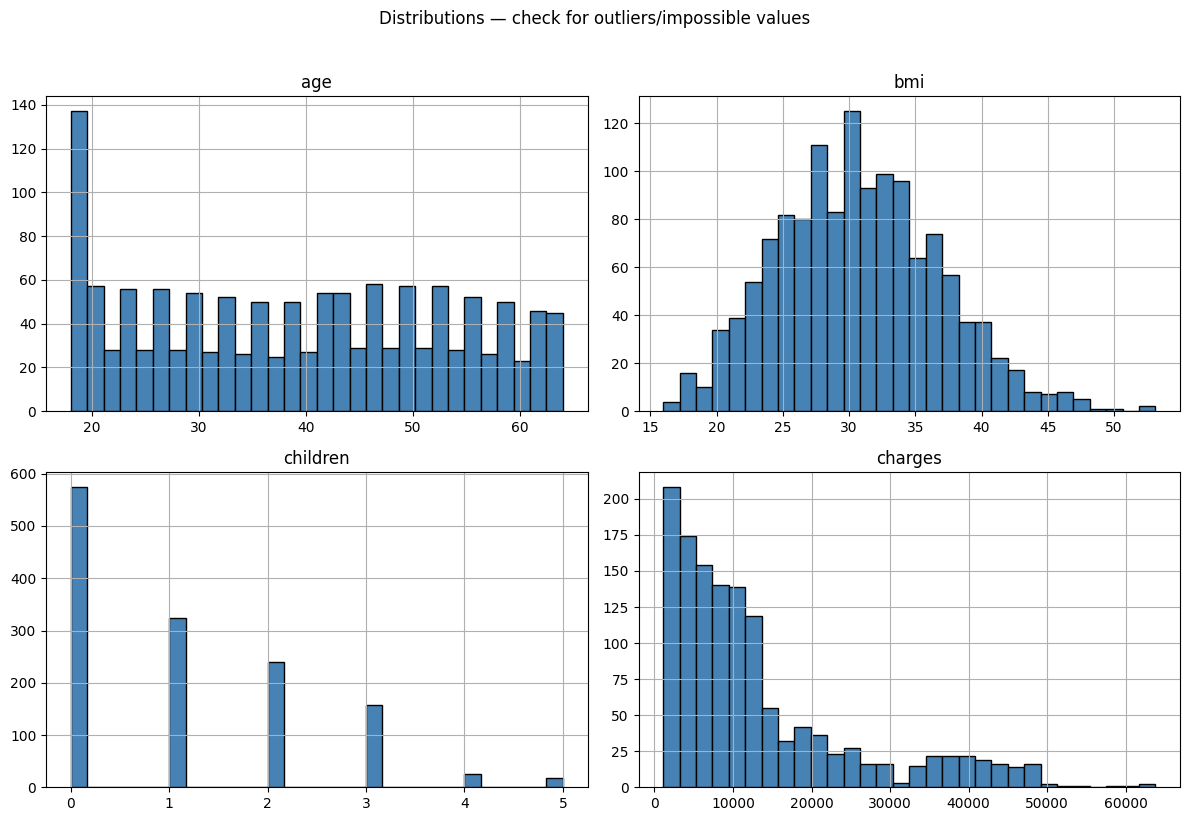


Rows with impossible values: 0

Cleaning done. Shape: (1338, 7)


In [4]:
# ── 1. NULL CHECK ──────────────────────────────────────────────────────────────
print("Null values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

# ── 2. HISTOGRAMS (spot impossible values) ─────────────────────────────────────

num_cols = ['age', 'bmi', 'children', 'charges']
df[num_cols].hist(bins=30, figsize=(12, 8), color='steelblue', edgecolor='black')
plt.suptitle('Distributions — check for outliers/impossible values', y=1.02)
plt.tight_layout()
plt.show()

# ── 3. VALID RANGES (domain knowledge) ────────────────────────────────────────
# age      : 0–120
# bmi      : 10–60  (extremes beyond this are physiologically implausible)
# children : 0–10
# charges  : > 0

invalid_mask = (
    (df['age'] < 0)    | (df['age'] > 120)   |
    (df['bmi'] < 10)   | (df['bmi'] > 60)    |
    (df['children'] < 0) | (df['children'] > 10) |
    (df['charges'] <= 0)
)
print(f"\nRows with impossible values: {invalid_mask.sum()}")

# ── 4. REPLACE IMPOSSIBLE VALUES WITH COLUMN MEAN ─────────────────────────────
for col, lo, hi in [('age', 0, 120), ('bmi', 10, 60),
                    ('children', 0, 10), ('charges', 0, 1e9)]:
    bad = (df[col] < lo) | (df[col] > hi)
    if bad.sum() > 0:
        df.loc[bad, col] = df[col].mean()
        print(f"  {col}: replaced {bad.sum()} invalid value(s) with mean ({df[col].mean():.2f})")

# ── 5. FILL ANY NULLS WITH MEAN (numerical only) ──────────────────────────────
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mean(), inplace=True)
        print(f"  {col}: filled nulls with mean")

print("\nCleaning done. Shape:", df.shape)

**DATA PREPROCESSING**

In [5]:
# ── DATA PREPROCESSING ────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# ── 1. LABEL ENCODE binary categoricals ───────────────────────────────────────
df['sex']   = le.fit_transform(df['sex'])      # female=0, male=1
df['smoker'] = le.fit_transform(df['smoker'])  # no=0, yes=1

# ── 2. ONE-HOT ENCODE 'region' (4 categories) ─────────────────────────────────
df = pd.get_dummies(df, columns=['region'], drop_first=True)  # drops one to avoid multicollinearity

# ── 3. CONVERT ALL ENCODED COLUMNS TO INT ─────────────────────────────────────
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})

# convert remaining float-encoded cols to int where applicable
for col in ['sex', 'smoker', 'children', 'age']:
    df[col] = df[col].astype(int)

# ── 4. FINAL CHECK ────────────────────────────────────────────────────────────
print(df.dtypes)
print("\nShape:", df.shape)
print(df.head())

age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int64
charges             float64
region_northwest      int64
region_southeast      int64
region_southwest      int64
dtype: object

Shape: (1338, 9)
   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400                 0   
1   18    1  33.770         1       0   1725.55230                 0   
2   28    1  33.000         3       0   4449.46200                 0   
3   33    1  22.705         0       0  21984.47061                 1   
4   32    1  28.880         0       0   3866.85520                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


In [6]:

df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


In [7]:
# ── STEP 1: FEATURE ENGINEERING (on raw df, before scaling) ──────────────────
df['smoker_bmi']  = df['smoker'] * df['bmi']
df['smoker_age']  = df['smoker'] * df['age']
df['age_squared'] = df['age'] ** 2

# ── STEP 2: STANDARD SCALER ───────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression

X = df.drop('charges', axis=1)
y = df['charges']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# ── STEP 3: FEATURE SELECTION ─────────────────────────────────────────────────
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_scaled, y)

feat_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score'  : selector.scores_,
    'P-value': selector.pvalues_
}).sort_values('Score', ascending=False)

print(feat_scores.to_string(index=False))

drop_cols = feat_scores[feat_scores['P-value'] > 0.05]['Feature'].tolist()
print(f"\nDropping: {drop_cols}")
X_scaled = X_scaled.drop(columns=drop_cols)
print("Final features:", X_scaled.columns.tolist())

         Feature       Score       P-value
      smoker_bmi 3339.047418  0.000000e+00
      smoker_age 2207.014573 3.155980e-285
          smoker 2177.614868 8.271436e-283
     age_squared  132.880633  2.234819e-29
             age  131.174013  4.886693e-29
             bmi   54.709308  2.459086e-13
region_southeast    7.352531  6.782699e-03
        children    6.206037  1.285213e-02
             sex    4.399702  3.613272e-02
region_southwest    2.499121  1.141466e-01
region_northwest    2.130837  1.445970e-01

Dropping: ['region_southwest', 'region_northwest']
Final features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_southeast', 'smoker_bmi', 'smoker_age', 'age_squared']


In [8]:
# merge scaled features back with target
final_df = X_scaled.copy()
final_df['charges'] = y.reset_index(drop=True)

print("Final DataFrame shape:", final_df.shape)
print(final_df.head())

Final DataFrame shape: (1338, 10)
        age       sex       bmi  children    smoker  region_southeast  \
0 -1.438764 -1.010519 -0.453320 -0.908614  1.970587         -0.611324   
1 -1.509965  0.989591  0.509621 -0.078767 -0.507463          1.635795   
2 -0.797954  0.989591  0.383307  1.580926 -0.507463          1.635795   
3 -0.441948  0.989591 -1.305531 -0.908614 -0.507463         -0.611324   
4 -0.513149  0.989591 -0.292556 -0.908614 -0.507463         -0.611324   

   smoker_bmi  smoker_age  age_squared      charges  
0    1.699463     0.66280    -1.220462  16884.92400  
1   -0.494516    -0.47041    -1.253341   1725.55230  
2   -0.494516    -0.47041    -0.844579   4449.46200  
3   -0.494516    -0.47041    -0.573551  21984.47061  
4   -0.494516    -0.47041    -0.631311   3866.85520  


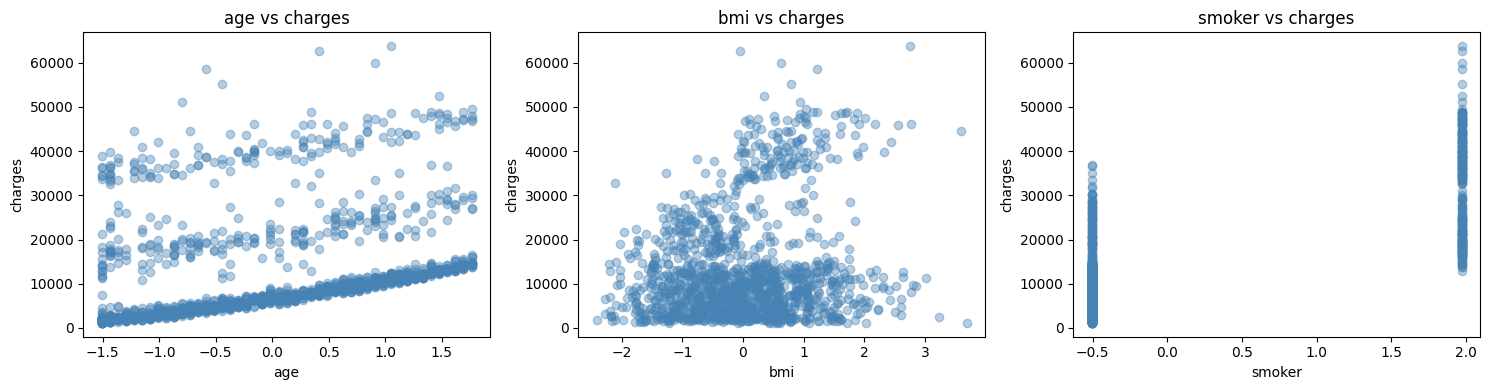

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['age', 'bmi', 'smoker']):
    ax.scatter(final_df[col], final_df['charges'], alpha=0.4, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('charges')
    ax.set_title(f'{col} vs charges')

plt.tight_layout()
plt.show()

Slope (m): 3622.3465
Intercept (c): 13270.4223
Equation: charges = 3622.35 * age + 13270.42


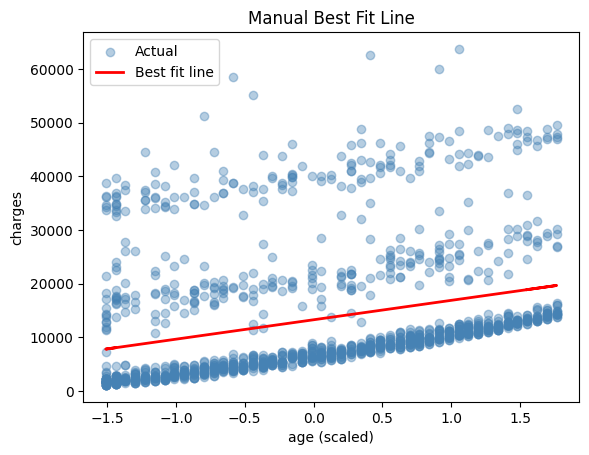

In [10]:
import numpy as np

# using age as example — y = mx + c
x = final_df['age'].values
y_vals = final_df['charges'].values

m = np.cov(x, y_vals)[0][1] / np.var(x)   # slope
c = np.mean(y_vals) - m * np.mean(x)       # intercept

print(f"Slope (m): {m:.4f}")
print(f"Intercept (c): {c:.4f}")
print(f"Equation: charges = {m:.2f} * age + {c:.2f}")

# plot it
plt.scatter(x, y_vals, alpha=0.4, color='steelblue', label='Actual')
plt.plot(x, m*x + c, color='red', linewidth=2, label='Best fit line')
plt.xlabel('age (scaled)')
plt.ylabel('charges')
plt.title('Manual Best Fit Line')
plt.legend()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

X_final = final_df.drop('charges', axis=1)
y_final = final_df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (1070, 9)
Test size : (268, 9)


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# evaluation
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 2793.76
MSE  : 20810456.08
RMSE : 4561.85
R²   : 0.8660


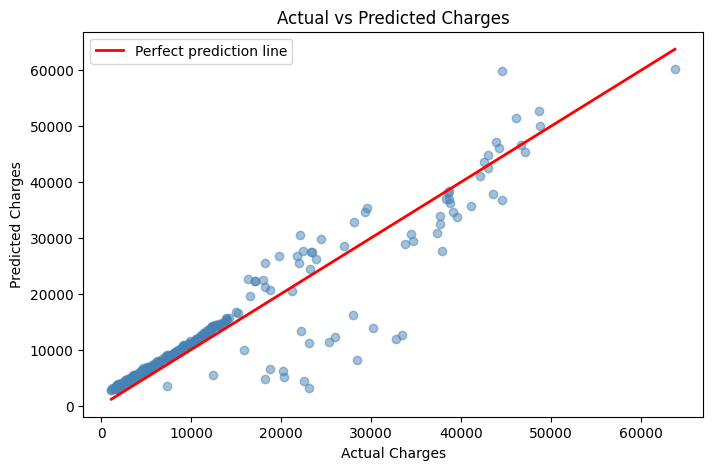

        Actual  Predicted
0   9095.06825   10166.70
1   5272.17580    6536.10
2  29330.98315   34625.61
3   9301.89355   10584.48
4  33750.29180   28824.22
5   4536.25900    6278.20
6   2117.33885    3627.80
7  14210.53595   15663.98
8   3732.62510    4825.38
9  10264.44210   11573.98


In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2, label='Perfect prediction line')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges')
plt.legend()
plt.show()

# side by side comparison
comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred.round(2)})
print(comparison.head(10))